<a href="https://colab.research.google.com/github/Isay-cz/cifar10-cnn-classifier/blob/main/notebooks/redes_neuronales_convolucionales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 799.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 105.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [5]:
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D
from tensorflow.keras.layers import Dropout, Flatten
from tensorflow.keras.datasets.cifar10 import load_data
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [6]:
(Xt, yt), (Xtest, ytest) = load_data()
print(Xt.shape)
print(yt.shape)
print(Xtest.shape)
print(ytest.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
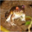

In [7]:
Xt[0]

In [8]:
np.unique(yt)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [9]:
yt

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

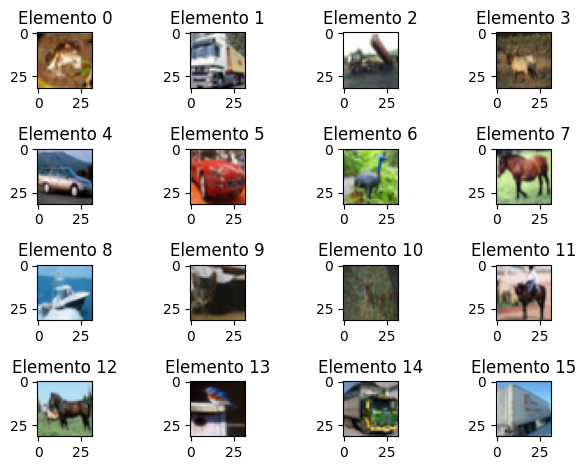

In [10]:
for i in range(16):
  plt.subplot(4, 4, i+1)
  plt.imshow(Xt[i], cmap='gray')
  plt.title(label=f"Elemento {i}")
plt.tight_layout()
plt.show()

In [11]:
Xt = Xt/255
Xtest = Xtest/255

In [12]:
Xt[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [13]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(Xt)

In [14]:
red = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPool2D((2,2)),
    Dropout(0.2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPool2D((2,2)),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2,2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [15]:
red.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
Xt = Xt.reshape(50000, 32, 32, 3)

In [17]:
Xtest = Xtest.reshape(10000, 32, 32, 3)

In [18]:
red.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = red.fit(
    datagen.flow(Xt, yt, batch_size=128),
    epochs=20,
    validation_data=(Xtest, ytest),
    verbose=1
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 163s 411ms/step - accuracy: 0.3177 - loss: 1.8892 - val_accuracy: 0.1586 - val_loss: 5.0398
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 157s 401ms/step - accuracy: 0.4344 - loss: 1.5529 - val_accuracy: 0.5264 - val_loss: 1.4442
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 404ms/step - accuracy: 0.4998 - loss: 1.3835 - val_accuracy: 0.5509 - val_loss: 1.3461
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 404ms/step - accuracy: 0.5521 - loss: 1.2554 - val_accuracy: 0.5161 - val_loss: 1.5874
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 159s 406ms/step - accuracy: 0.5905 - loss: 1.1616 - val_accuracy: 0.6064 - val_loss: 1.1631
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 159s 407ms/step - accuracy: 0.6156 - loss: 1.0917 - val_accuracy: 0.6302 - val_loss: 1.1585
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 159s 407ms/step - accuracy: 0.6422 - loss: 1.0238 - val_accuracy: 0.5891 - val_loss: 1.2125
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 403ms/step - accuracy: 0.6596 -

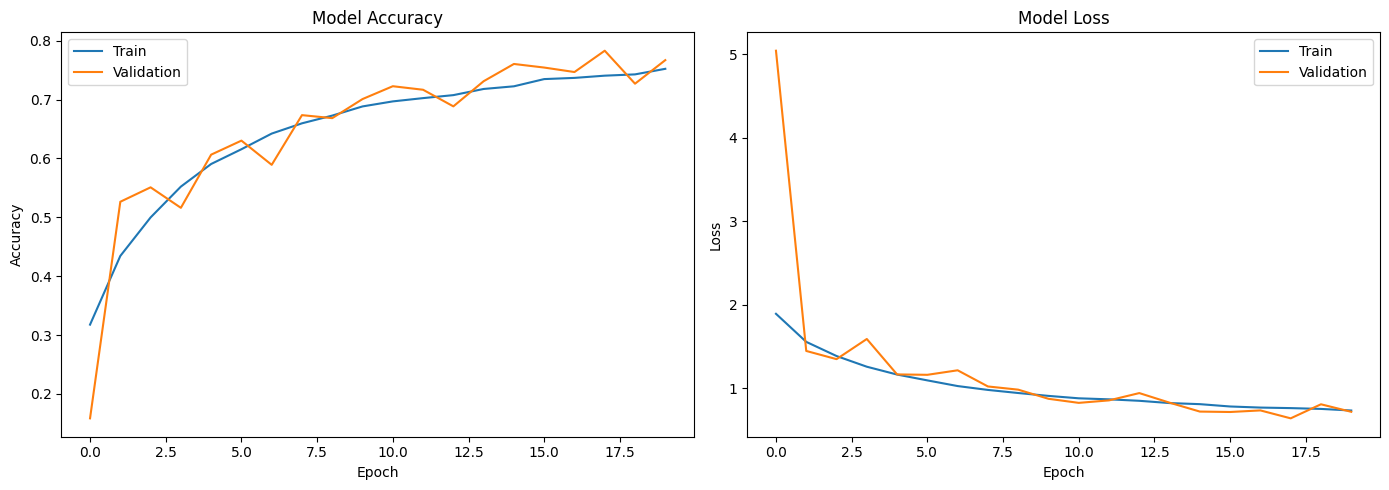

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [20]:
loss, acc = red.evaluate(Xt, yt)
print(f"Precision = {acc*100}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7851 - loss: 0.6466
Precision = 78.50599884986877


In [21]:
loss, acc = red.evaluate(Xtest, ytest)
print(f"Precision = {acc*100}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7669 - loss: 0.7156
Precision = 76.69000029563904


In [22]:
respuestas = []
reales = []
for i in range (100):
  respuestas.append(np.argmax(red.predict(Xt[i].reshape(1, 32, 32, 3), verbose=0)))
  reales.append(yt[i])

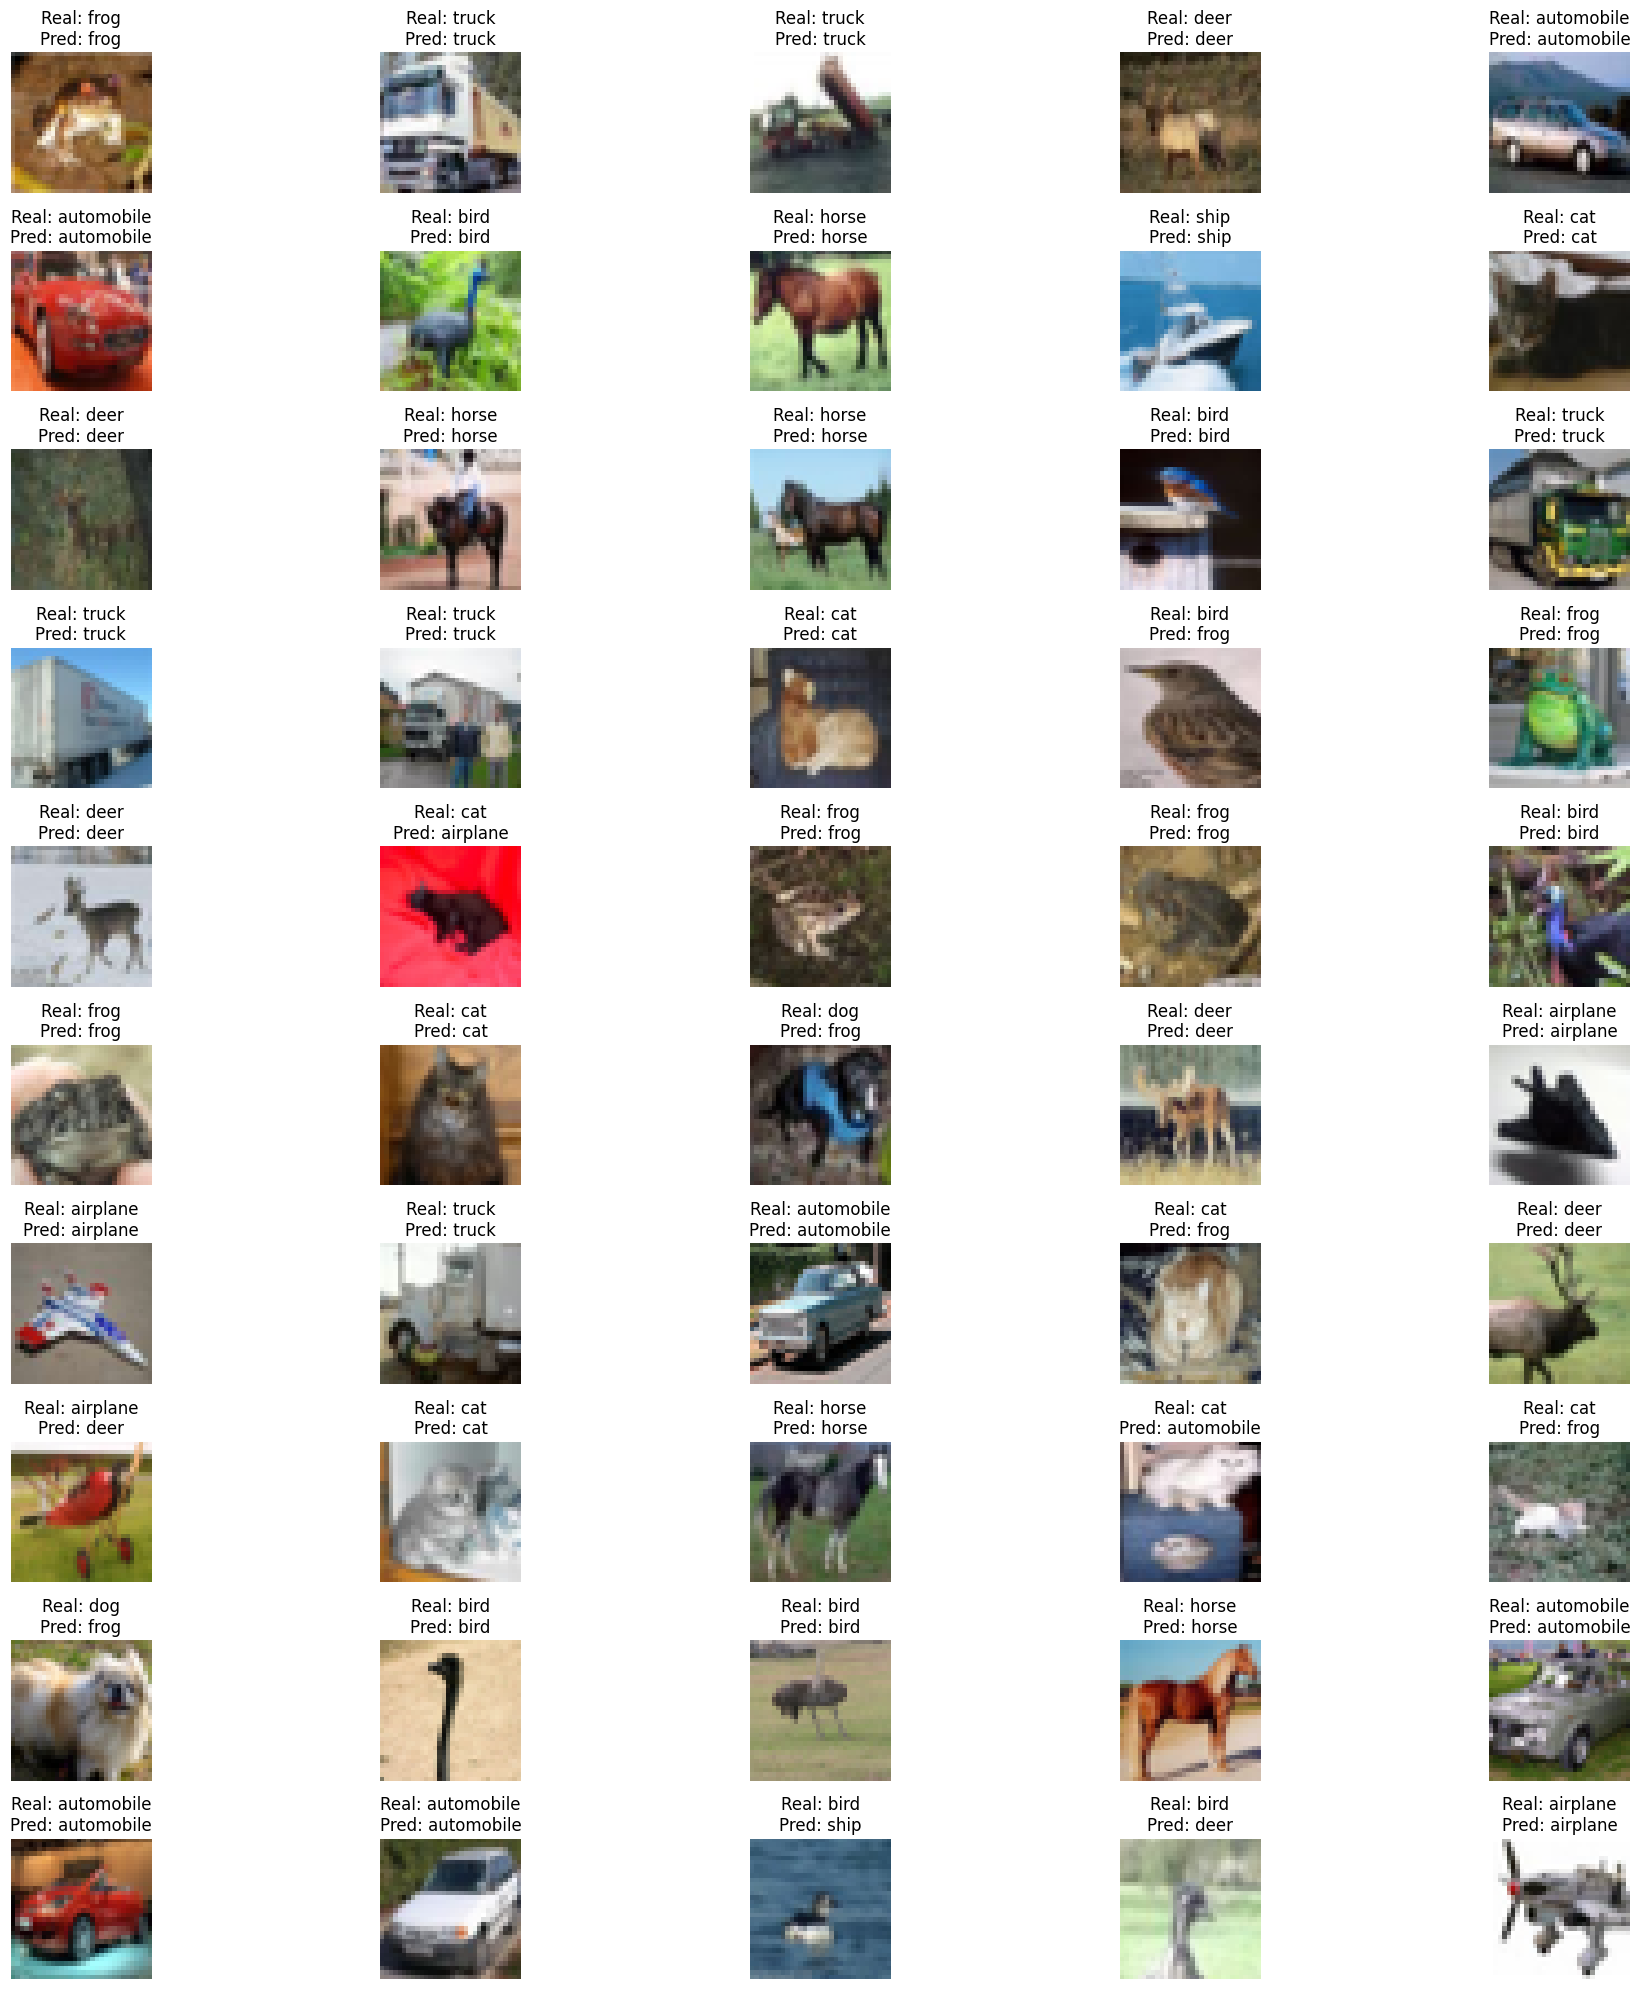

In [23]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(20, 20))
for i in range(50):
    plt.subplot(10, 5, i+1)
    plt.imshow(Xt[i])
    plt.title(f"Real: {class_names[reales[i][0]]}\nPred: {class_names[respuestas[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Conclusiones
#Arquitectura: CNN custom — 3 bloques Conv2D + BatchNorm + MaxPool + Dropout
#Parámetros totales: 667,434 (~2.5 MB)

# Resultados finales (20 épocas con data augmentation):
- Train accuracy:      78.51%
- Test accuracy:       76.69%
- Gap train/test:      ~1.8 pp — overfitting bien controlado

# Evolución del proyecto:
- v1 (sin augmentation, 10 épocas): test accuracy 73.17%, gap ~3.3 pp
- v2 (con augmentation, 20 épocas): test accuracy 76.69%, gap ~1.8 pp
- → +3.5 pp de accuracy, reducción de overfitting del 45%

# Limitaciones y siguiente iteración:
- El techo práctico de CNNs custom en CIFAR-10 (32x32px) es ~80-83%.
- Superar ese umbral requiere transfer learning (ResNet50, EfficientNetB0).